<a href="https://colab.research.google.com/github/evieholt63/Lte1-m-cell-segmentation-analysis/blob/main/Localization_Data_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#BLOCK 1: SET-UP
#Install Cellpose & Scientific Python Imaging Libraries
%pip install -q cellpose tifffile scikit-image pandas matplotlib scipy


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 213.4/213.4 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.8/6.8 MB 51.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 34.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.5/26.5 MB 27.2 MB/s eta 0:00:00


In [ ]:
#BLOCK 2: SET-UP
#Load Libraries for Cell Segmentation and Feature Extraction
import os
import numpy as np
import pandas as pd
import tifffile
import matplotlib.pyplot as plt

from skimage.filters import laplace
from skimage.measure import regionprops
from scipy.ndimage import binary_dilation

from cellpose import models, core, plot


In [ ]:
#BLOCK 3: SET-UP
#Mount Google Drive for Data Access
from google.colab import drive
drive.mount("/content/drive", force_remount=True)


Mounted at /content/drive


In [ ]:
#BLOCK 4: Set Up Output Directory for Results
import os

# ---- MASTER OUTPUT FOLDER ----
OUTPUT_ROOT = "/content/drive/My Drive/Lte_m_Localization_Data_1"

# Create folder if it doesn't exist
os.makedirs(OUTPUT_ROOT, exist_ok=True)

print("Results will save to:", OUTPUT_ROOT)


Results will save to: /content/drive/My Drive/Lte_m_Localization_Data_1


In [ ]:
#BLOCK 5: Retrieve and Sort Microscopy Image Files (TIFs)
ROOT = "/content/drive/My Drive/Microscopy_Analysis/75_TF2_02"

files = sorted([f for f in os.listdir(ROOT) if f.endswith(".tif")])
print("TIFF files found:", len(files))
files


TIFF files found: 33


['10X Brightfield GFP_Z001_CH1.tif',
 '10X Brightfield GFP_Z001_CH2.tif',
 '10X Brightfield GFP_Z001_CH4.tif',
 '10X Brightfield GFP_Z002_CH1.tif',
 '10X Brightfield GFP_Z002_CH2.tif',
 '10X Brightfield GFP_Z002_CH4.tif',
 '10X Brightfield GFP_Z003_CH1.tif',
 '10X Brightfield GFP_Z003_CH2.tif',
 '10X Brightfield GFP_Z003_CH4.tif',
 '10X Brightfield GFP_Z004_CH1.tif',
 '10X Brightfield GFP_Z004_CH2.tif',
 '10X Brightfield GFP_Z004_CH4.tif',
 '10X Brightfield GFP_Z005_CH1.tif',
 '10X Brightfield GFP_Z005_CH2.tif',
 '10X Brightfield GFP_Z005_CH4.tif',
 '10X Brightfield GFP_Z006_CH1.tif',
 '10X Brightfield GFP_Z006_CH2.tif',
 '10X Brightfield GFP_Z006_CH4.tif',
 '10X Brightfield GFP_Z007_CH1.tif',
 '10X Brightfield GFP_Z007_CH2.tif',
 '10X Brightfield GFP_Z007_CH4.tif',
 '10X Brightfield GFP_Z008_CH1.tif',
 '10X Brightfield GFP_Z008_CH2.tif',
 '10X Brightfield GFP_Z008_CH4.tif',
 '10X Brightfield GFP_Z009_CH1.tif',
 '10X Brightfield GFP_Z009_CH2.tif',
 '10X Brightfield GFP_Z009_CH4.tif',
 

In [ ]:
#BLOCK 6
#Automatically grab dataset name
dataset_name = os.path.basename(ROOT)

print("Dataset:", dataset_name)

Dataset: 75_TF2_02


In [ ]:
#BLOCK 7
#Separate Image Files by Channel (BF, DAPI, GFP)
bf_files   = sorted([f for f in files if "_CH4" in f])
dapi_files = sorted([f for f in files if "_CH1" in f])
gfp_files  = sorted([f for f in files if "_CH2" in f])

print(len(bf_files), len(dapi_files), len(gfp_files))


11 11 11


In [ ]:
#BLOCK 8: Load and Stack Z-Slice Images by Channel

# concatenate z slices to make stacks
def load_stack(file_list, channel=None):
    stack = []

    for f in file_list:
        img = tifffile.imread(os.path.join(ROOT, f))

        # if image has channels, select the requested one
        if channel is not None and img.ndim == 3:
            img = img[:, :, channel]

        stack.append(img)

    return np.stack(stack)

bf_stack   = load_stack(bf_files)
dapi_stack = load_stack(dapi_files, channel=2)  # third channel
gfp_stack  = load_stack(gfp_files, channel=1)   # second channel

print(bf_stack.shape)
print(dapi_stack.shape)
print(gfp_stack.shape)


(11, 480, 640)
(11, 480, 640)
(11, 480, 640)


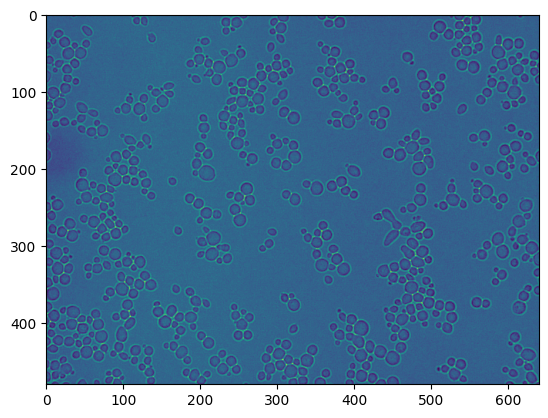

In [ ]:
#BLOCK 9: Quick Preview of Selected Slice from BF/DAPI/GFP Stack
plt.imshow(bf_stack[6])
# plt.imshow(dapi_stack[6])
# plt.imshow(gfp_stack[0])
plt.show()

In [ ]:
#BLOCK 10: Determine Optimal Focus Slice for Each Channel
def best_focus_index(stack):
    scores = [np.var(laplace(img)) for img in stack]
    return int(np.argmax(scores)), scores

bf_z, _   = best_focus_index(bf_stack)
dapi_z, _ = best_focus_index(dapi_stack)
gfp_z, _  = best_focus_index(gfp_stack)

bf_image   = bf_stack[bf_z]
dapi_image = dapi_stack[dapi_z]
gfp_image  = gfp_stack[gfp_z]

print("Best Z:", bf_z, dapi_z, gfp_z)


Best Z: 8 8 9


In [ ]:
#BLOCK 11: Detect Cells Using Cellpose Model (Segementation)

use_gpu = core.use_gpu()
print("GPU available:", use_gpu)

model = models.CellposeModel(gpu=use_gpu)

masks, flows, styles = model.eval(bf_image)

print("Cells segmented:", masks.max())


GPU available: True
Cells segmented: 626


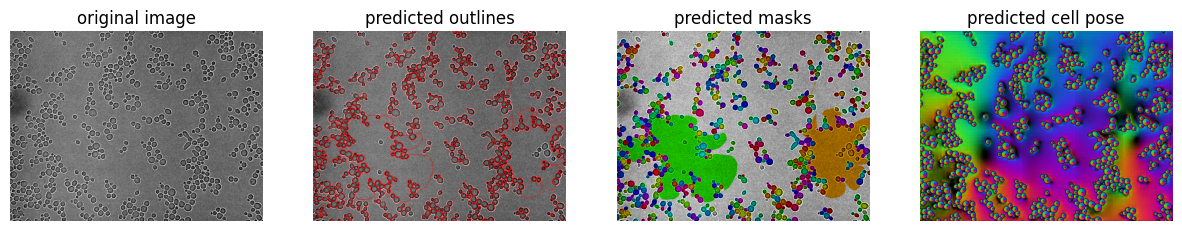

In [ ]:
#BLOCK 12: Visualize Cellpose Segmentation Results (OG Image, Outlines, Masks, Cellpose)
fig = plt.figure(figsize=(15,9))
plot.show_segmentation(fig, bf_image, masks, flows[0])

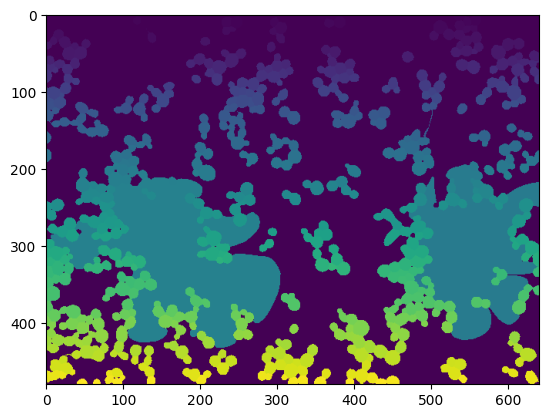

In [ ]:
#BLOCK 13: Visualize Segmentation Mask
plt.imshow(masks)
plt.show()

In [ ]:
# BLOCK 14: Save Mask Image to Data Output Folder (previously set up in BLOCK 4)
mask_name = f"{dataset_name}_masks.tif"
mask_path = os.path.join(OUTPUT_ROOT, mask_name)
tifffile.imwrite(mask_path, masks.astype(np.uint16))

print(f"mask {mask_name} saved!")

mask 75_TF2_02_masks.tif saved!


In [ ]:
#BLOCK 15: Filter and Assign Mother–Daughter Relationships from Segementation
regions = {r.label: r for r in regionprops(masks)}
mother_daughter_pairs = []
min_area = 10

for label, region in regions.items():

    # Skip small cells
    if region.area < min_area:
        continue

    cell_mask = (masks == label)
    dilated = binary_dilation(cell_mask)

    neighbors = np.unique(masks[dilated])
    neighbors = neighbors[(neighbors != 0) & (neighbors != label)]

    # Reject crowded cells
    if len(neighbors) > 2:
        continue

    for n in neighbors:
        if n not in regions:
            continue

        # Assign mother/daughter by size
        if region.area > regions[n].area:
            mother, daughter = label, n
        else:
            mother, daughter = n, label

        # Bud size constraint
        if regions[daughter].area >= 0.99 * regions[mother].area:
            continue

        mother_daughter_pairs.append((mother, daughter))

mother_daughter_pairs = list(set(mother_daughter_pairs))
print("Candidate pairs:", (mother_daughter_pairs))
print("Len Candidate pairs:", len(mother_daughter_pairs))


Candidate pairs: [(155, np.uint16(181)), (np.uint16(595), 605), (np.uint16(99), 109), (np.uint16(437), 424), (np.uint16(71), 56), (np.uint16(276), 345), (431, np.uint16(438)), (np.uint16(403), 385), (np.uint16(243), 256), (np.uint16(324), 339), (51, np.uint16(73)), (np.uint16(206), 203), (247, np.uint16(250)), (np.uint16(365), 385), (609, np.uint16(611)), (np.uint16(276), 331), (np.uint16(261), 431), (np.uint16(140), 132), (np.uint16(251), 256), (442, np.uint16(452)), (np.uint16(77), 103), (169, np.uint16(186)), (np.uint16(92), 110), (np.uint16(261), 278), (202, np.uint16(210)), (np.uint16(225), 221), (np.uint16(276), 443), (74, np.uint16(79)), (np.uint16(576), 564), (np.uint16(365), 362), (np.uint16(545), 567), (155, np.uint16(171)), (np.uint16(67), 58), (np.uint16(557), 541), (597, np.uint16(614)), (65, np.uint16(88)), (np.uint16(449), 459), (358, np.uint16(350)), (np.uint16(280), 278), (58, np.uint16(76)), (np.uint16(139), 162), (np.uint16(111), 91), (450, np.uint16(451)), (40, np.u

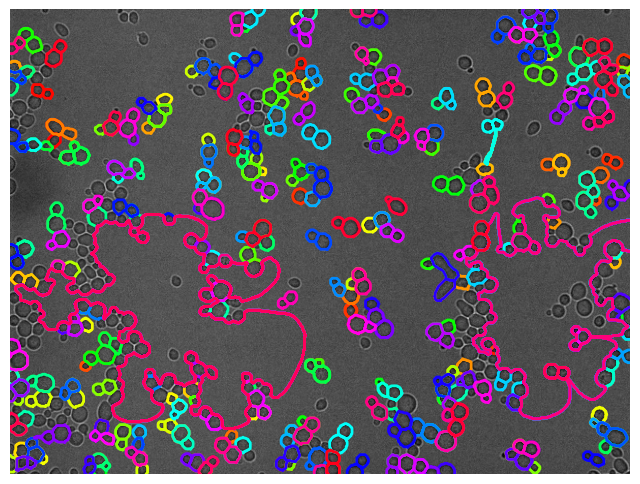

In [ ]:
#BLOCK 16: Plot Matched Mother–Daughter Cell Boundaries
import matplotlib.pyplot as plt
from skimage.measure import find_contours
import numpy as np

def plot_mother_daughter_contours(image, masks, pairs):
    plt.figure(figsize=(8,8))
    plt.imshow(image, cmap="gray")

    # updated colormap call
    cmap = plt.get_cmap("hsv", len(pairs))

    for i, (mother, daughter) in enumerate(pairs):
        color = cmap(i)

        mother_mask = (masks == mother)
        daughter_mask = (masks == daughter)

        mother_contours = find_contours(mother_mask, 0.5)
        daughter_contours = find_contours(daughter_mask, 0.5)

        for c in mother_contours:
            plt.plot(c[:,1], c[:,0], color=color, linewidth=2)

        for c in daughter_contours:
            plt.plot(c[:,1], c[:,0], color=color, linewidth=2)

    plt.axis("off")
    plt.show()

plot_mother_daughter_contours(bf_image, masks, mother_daughter_pairs)

Valid mother–daughter pairs after DAPI gating: 163


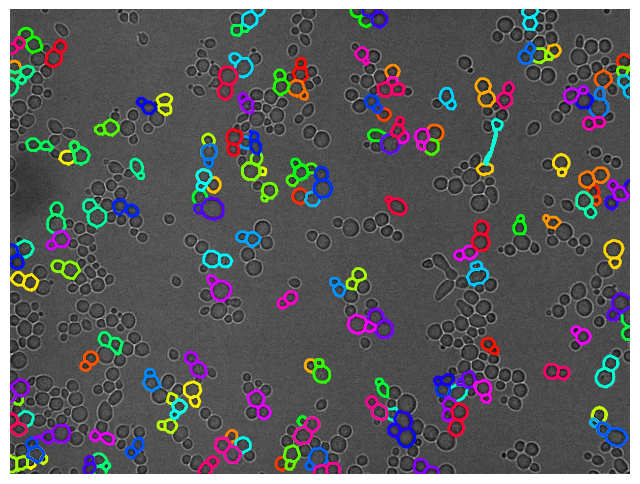

In [ ]:
# BLOCK 17: Filter Mother–Daughter Pairs Using DAPI Intensity Gating

valid_pairs = []

for mother, daughter in mother_daughter_pairs:

    mother_pixels = dapi_image[masks == mother]
    daughter_pixels = dapi_image[masks == daughter]

    if len(mother_pixels) == 0 or len(daughter_pixels) == 0:
        continue

    mother_dapi = np.mean(mother_pixels)
    daughter_dapi = np.mean(daughter_pixels)

    # --- RELATIVE RULE ---
    # Mother must be brighter than daughter by factor
    if mother_dapi > 1.001 * daughter_dapi:

        valid_pairs.append({
            "mother_label": mother,
            "daughter_label": daughter,
            "mother_dapi": mother_dapi,
            "daughter_dapi": daughter_dapi
        })

print("Valid mother–daughter pairs after DAPI gating:",
      len(valid_pairs))


mother_daughter_tuples = [(p["mother_label"], p["daughter_label"])for p in valid_pairs]
plot_mother_daughter_contours(bf_image, masks, mother_daughter_tuples)

In [ ]:
#BLOCK 18: Quantify GFP Intensity and Morphology in Mother–Daughter Pairs

regions = {r.label: r for r in regionprops(masks)}
results = []

for pair in valid_pairs:

    m = pair["mother_label"]
    d = pair["daughter_label"]

    mother_pixels = gfp_image[masks == m]
    daughter_pixels = gfp_image[masks == d]

    # Skip only if masks somehow empty (safety check)
    if len(mother_pixels) == 0 or len(daughter_pixels) == 0:
        continue

    mother_gfp = np.mean(mother_pixels)
    daughter_gfp = np.mean(daughter_pixels)

    ratio = daughter_gfp / mother_gfp if mother_gfp > 0 else np.nan

    results.append({
        "Mother cell label number": m,
        "Mother cell average GFP intensity": mother_gfp,
        "Mother major axis length": regions[m].major_axis_length,
        "Mother minor axis length": regions[m].minor_axis_length,
        "Daughter cell label number": d,
        "Daughter cell average GFP intensity": daughter_gfp,
        "Daughter/Mother GFP intensity ratio": ratio,
        "Daughter major axis length": regions[d].major_axis_length,
        "Daughter minor axis length": regions[d].minor_axis_length,
    })

df = pd.DataFrame(results)

print("Rows in GFP table:", len(df))
df.head()


Rows in GFP table: 163


,Mother cell label number,Mother cell average GFP intensity,Mother major axis length,Mother minor axis length,Daughter cell label number,Daughter cell average GFP intensity,Daughter/Mother GFP intensity ratio,Daughter major axis length,Daughter minor axis length
0,595,3128.842857,14.168766,12.750268,605,3941.781818,1.259821,9.050542,7.807080
1,71,2852.219512,15.012097,14.127399,56,2784.320513,0.976194,10.635654,9.381562
2,431,3392.288136,12.694723,11.840460,438,7206.104167,2.124261,8.042946,7.725673
3,243,3854.700855,12.951472,11.610017,256,10813.928571,2.805387,8.784664,8.175878
4,51,3445.544218,14.480973,13.088491,73,6393.616279,1.855619,12.731565,9.299258


In [ ]:
#BLOCK 19: Quantify GFP, Assess Cell Polarity, and Generate Summary Metrics

regions = {r.label: r for r in regionprops(masks)}
results = []

# --- Define elongation threshold ---
ELONGATION_THRESHOLD = 1.5

for pair in valid_pairs:

    m = pair["mother_label"]
    d = pair["daughter_label"]

    mother_pixels = gfp_image[masks == m]
    daughter_pixels = gfp_image[masks == d]

    if len(mother_pixels) == 0 or len(daughter_pixels) == 0:
        continue

    # --- GFP ---
    mother_gfp = np.mean(mother_pixels)
    daughter_gfp = np.mean(daughter_pixels)
    ratio = daughter_gfp / mother_gfp if mother_gfp > 0 else np.nan

    # --- Morphology ---
    m_major = regions[m].major_axis_length
    m_minor = regions[m].minor_axis_length
    d_major = regions[d].major_axis_length
    d_minor = regions[d].minor_axis_length

    # --- Aspect ratio ---
    m_aspect = m_major / m_minor if m_minor > 0 else np.nan
    d_aspect = d_major / d_minor if d_minor > 0 else np.nan

    # --- Classification ---
    m_class = "elongated" if m_aspect >= ELONGATION_THRESHOLD else "normal"
    d_class = "elongated" if d_aspect >= ELONGATION_THRESHOLD else "normal"

    results.append({
        "Mother label": m,
        "Mother GFP": mother_gfp,
        "Mother aspect ratio": m_aspect,
        "Mother polarity": m_class,

        "Daughter label": d,
        "Daughter GFP": daughter_gfp,
        "Daughter/Mother GFP ratio": ratio,
        "Daughter aspect ratio": d_aspect,
        "Daughter polarity": d_class,
    })

df = pd.DataFrame(results)

print("Rows in GFP + polarity table:", len(df))
display(df.head())


# =====================================================
# SUMMARY TABLE (PER DATASET / MUTANT)
# =====================================================

summary = {
    "Total cells": len(df),
    "Mother elongated (%)": (df["Mother polarity"] == "elongated").mean() * 100,
    "Daughter elongated (%)": (df["Daughter polarity"] == "elongated").mean() * 100,
}

summary_df = pd.DataFrame([summary])
print("\nPolarity summary:")
display(summary_df)

Rows in GFP + polarity table: 163


,Mother label,Mother GFP,Mother aspect ratio,Mother polarity,Daughter label,Daughter GFP,Daughter/Mother GFP ratio,Daughter aspect ratio,Daughter polarity
0,595,3128.842857,1.111252,normal,605,3941.781818,1.259821,1.159274,normal
1,71,2852.219512,1.062623,normal,56,2784.320513,0.976194,1.133676,normal
2,431,3392.288136,1.072148,normal,438,7206.104167,2.124261,1.041067,normal
3,243,3854.700855,1.115543,normal,256,10813.928571,2.805387,1.074461,normal
4,51,3445.544218,1.106390,normal,73,6393.616279,1.855619,1.369095,normal



Polarity summary:


,Total cells,Mother elongated (%),Daughter elongated (%)
0,163,2.453988,11.042945


In [ ]:
#BLOCK 20: Save GFP Analysis Results to CSV File
df = pd.DataFrame(results)
display(df)

csv_name = f"{dataset_name}_GFP_results.csv"
output_path = os.path.join(OUTPUT_ROOT, csv_name)

df.to_csv(output_path, index=False)

print("CSV saved:", output_path)
print("Rows saved:", len(df))


,Mother label,Mother GFP,Mother aspect ratio,Mother polarity,Daughter label,Daughter GFP,Daughter/Mother GFP ratio,Daughter aspect ratio,Daughter polarity
0,595,3128.842857,1.111252,normal,605,3941.781818,1.259821,1.159274,normal
1,71,2852.219512,1.062623,normal,56,2784.320513,0.976194,1.133676,normal
2,431,3392.288136,1.072148,normal,438,7206.104167,2.124261,1.041067,normal
3,243,3854.700855,1.115543,normal,256,10813.928571,2.805387,1.074461,normal
4,51,3445.544218,1.106390,normal,73,6393.616279,1.855619,1.369095,normal
...,...,...,...,...,...,...,...,...,...
158,262,3235.026786,1.318068,normal,257,4774.600000,1.475907,1.160861,normal
159,520,2911.033333,1.074899,normal,543,2772.431579,0.952387,1.125426,normal
160,303,3009.907173,1.035319,normal,285,3694.685897,1.227508,1.039404,normal
161,45,2108.359813,1.136694,normal,35,2600.500000,1.233423,1.024676,normal


CSV saved: /content/drive/My Drive/Lte_m_Localization_Data_1/75_TF2_02_GFP_results.csv
Rows saved: 163


Saved QC image: /content/drive/My Drive/Lte_m_Localization_Data_1/75_TF2_02_QC_labeled_cells.png


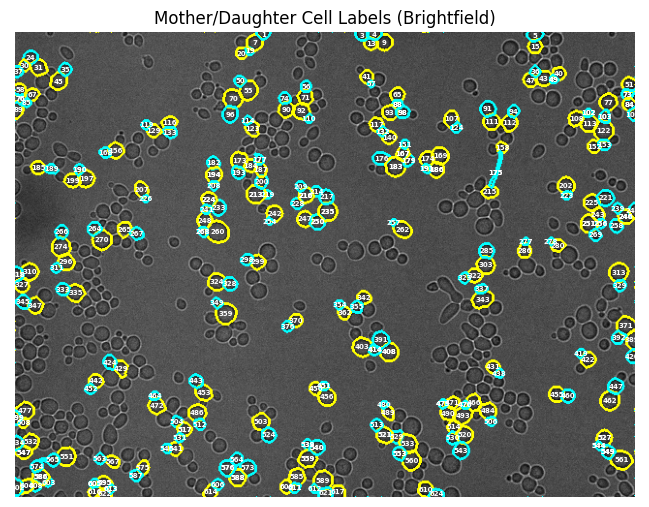

In [ ]:
#BLOCK 21 Generate and Save Labeled QC Image with Mother–Daughter Cell Boundaries
from skimage.segmentation import find_boundaries
from skimage.measure import regionprops
import matplotlib.pyplot as plt
import numpy as np
import os

# --- Normalize brightfield ---
bf_norm = bf_image.astype(float)
bf_norm = (bf_norm - bf_norm.min()) / (np.ptp(bf_norm) + 1e-9)

rgb = np.dstack([bf_norm, bf_norm, bf_norm])

regions = {r.label: r for r in regionprops(masks)}

# ---------- DRAW OUTLINES ----------
for pair in valid_pairs:
    m = int(pair["mother_label"])
    d = int(pair["daughter_label"])

    for label in [m, d]:
        if label in regions:
            cell_mask = (masks == label)
            boundary = find_boundaries(cell_mask, mode='outer')

            # Thin dilation (1 pixel)
            thick = (
                boundary |
                np.roll(boundary, 1, axis=0) |
                np.roll(boundary, -1, axis=0) |
                np.roll(boundary, 1, axis=1) |
                np.roll(boundary, -1, axis=1)
            )

            if label == m:
                rgb[thick] = [1, 1, 0]  # MAGENTA
            else:
              rgb[thick] = [0, 1, 1]  # CYAN

# ---------- DISPLAY IMAGE ----------
plt.figure(figsize=(8,8))
plt.imshow(rgb)
plt.axis("off")

# ---------- ADD LABELS ----------
for pair in valid_pairs:
    m = int(pair["mother_label"])
    d = int(pair["daughter_label"])

    if m in regions:
        cy, cx = regions[m].centroid
        plt.text(cx, cy, f"{m}", color='white',
                 fontsize=5, weight='bold',
                 ha='center', va='center')

    if d in regions:
        cy, cx = regions[d].centroid
        plt.text(cx, cy, f"{d}", color='white',
                 fontsize=5, weight='bold',
                 ha='center', va='center')

plt.title("Mother/Daughter Cell Labels (Brightfield)")
# ---- SAVE LABELED IMAGE ----
qc_name = f"{dataset_name}_QC_labeled_cells.png"
qc_path = os.path.join(OUTPUT_ROOT, qc_name)

plt.savefig(qc_path, dpi=300, bbox_inches='tight')
print("Saved QC image:", qc_path)

plt.show()

